In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

0.45269321722152


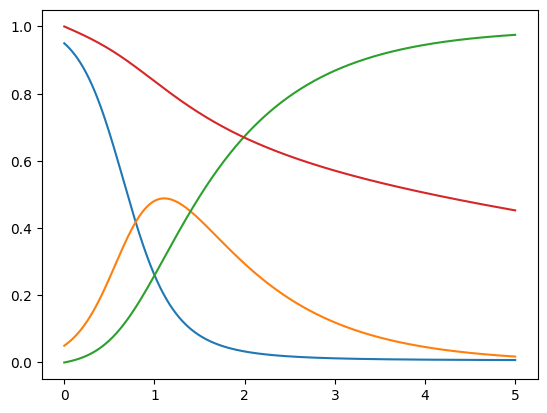

In [3]:
mu = 0.1
ddt = lambda p,t: np.array([-mu*p[0], mu*p[0]])
ic = np.array([0.95,0.05,0,1,0]) # Alive, dead,S,I,R
R0 = 5
def ddt(u,t):
    dudt = np.zeros(5)
    dudt[0] = -R0 * u[0]*u[1]
    dudt[1] = R0*u[0] * u[1] - u[1]
    dudt[2] = u[1]
    dudt[3] = -mu*(1+3*u[1])*u[3]
    dudt[4] = mu*(1+3*u[1])*u[3]
    return dudt
    

t = np.linspace(0,5,1000)
y0 = spi.odeint(ddt, ic, t)

alive_pandemic = y0[:,3]

plt.plot(t, y0[:,0:4])
print(y0[999,3])

0.6065306448427146


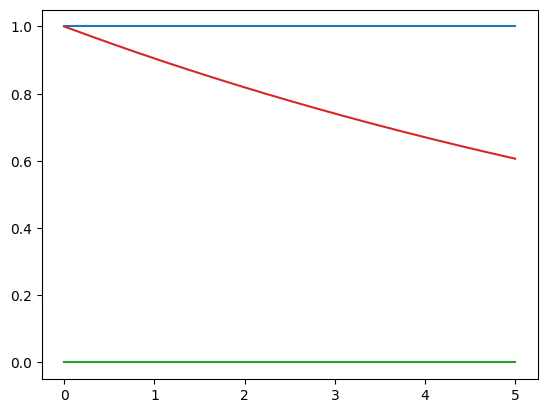

In [4]:
mu = 0.1
ddt = lambda p,t: np.array([-mu*p[0], mu*p[0]])
ic = np.array([1,0.00,0,1,0]) # Alive, dead,S,I,R
R0 = 5
def ddt(u,t):
    dudt = np.zeros(5)
    dudt[0] = -R0 * u[0]*u[1]
    dudt[1] = R0*u[0] * u[1] - u[1]
    dudt[2] = u[1]
    dudt[3] = -mu*(1+3*u[1])*u[3]
    dudt[4] = mu*(1+3*u[1])*u[3]
    return dudt
    

t = np.linspace(0,5,1000)
y1 = spi.odeint(ddt, ic, t)

alive_no_pandemic = y1[:,3]

plt.plot(t, y1[:,0:4])
print(y1[999,3])

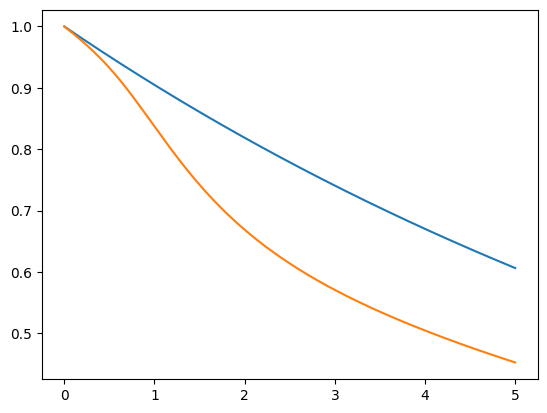

In [5]:
# plt.plot(t,alive_pandemic,alive_no_pandemic)
plt.plot(t, y1[:,3])
plt.plot(t, y0[:,3])
plt.show()

## Expected Present Value of Insurance

EPV of Benefits
$$EPV(\text{Benefit}) = DB \cdot \bar{A}_x$$
where $DB$ is the death benefit and $\bar{A}_x$ is the present value of a continuous whole life insurance of $\$1$
$$\bar{A}_x = \int_{0}^{\infty} v^t \cdot {}_t p_x \mu_{x+t} \, dt$$


EPV of Premiums
$$EPV(\text{Premium}) = P \cdot \bar{a}_x$$
Where $P$ is the annual premium, and $\bar{a}_x$ is the present value of a continuous whole life annuity paying $\$1$ yearly.
$$\bar{a}_x = \int_{0}^{\infty} v^t \cdot {}_t p_x \, dt$$


We investigate how a Pandemic affects the force of mortality $\mu_{x+t}$ and survival probability $_t p_x$ using the SIR model, in order to determine how a pandemic will affect the expected profitability of a life insurance product.


The non-dimensionalized SIR model
$$\begin{aligned}
\frac{ds^*}{dt} &= -\frac{\beta N}{\gamma} s^*i^*\\
\frac{di^*}{dt} &= \frac{\beta N}{\gamma} s^*i^* - i^*\\
\frac{dr^*}{dt} &=   i^* \\
&\qquad s^*(0) = s^*_0, \,\,
i^*(0) = i^*_0,\,\,
r^*(0) = r^*_0.
\end{aligned}
$$

Gives the proportion of the total population infected. We assume that higher infection in a population during a pandemic will translate to higher mortality rates for policyholders, so we link infection rate to to the mortality rate $\mu_{x+t}$. 

$$\mu_{x+t} = \mu_0 (1 + m \cdot i^*)$$

we can use Kolmogorov's forward equation to calculate $_t p_x$ and integrate to find the difference in the EPV.

$$\frac{d}{dt} {}_t p_x^{ij} = \sum_{k=0, k \neq j}^{m} \left( {}_t p_x^{ik} \mu_{x+t}^{kj} - {}_t p_x^{ij} \mu_{x+t}^{jk} \right)$$

for whole life, this simplifies to
$$\frac{d}{dt} {}_t p_x^{00} = -\mu_{x+t} \cdot {}_t p_x^{00}$$

0.45269321722152
0.4987212583481295
-0.29744166243275727
Loss of:  0.20127959591537226


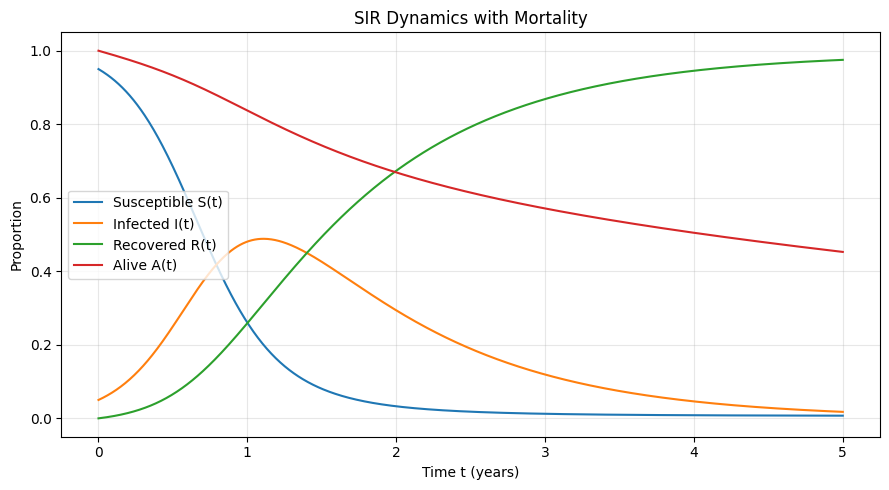

In [10]:
mu = 0.1
mort_factor = 3
delta = 0.05 # force of interest
ddt = lambda p,t: np.array([-mu*p[0], mu*p[0]])
ic = np.array([0.95,0.05,0,1,0]) # S,I,R,Alive, dead
R0 = 5
def ddt(u,t):
    dudt = np.zeros(5)
    dudt[0] = -R0 * u[0]*u[1]
    dudt[1] = R0*u[0] * u[1] - u[1]
    dudt[2] = u[1]
    dudt[3] = -mu*(1+mort_factor*u[1])*u[3]
    dudt[4] = mu*(1+mort_factor*u[1])*u[3]
    return dudt
    

t = np.linspace(0,5,1000)
y0 = spi.odeint(ddt, ic, t)

alive_pandemic = y0[:,3]

# plt.plot(t, y0[:,0:4])
print(y0[999,3])
tpx = y0[:,3]
mu_xt = mu*(1+mort_factor*y0[:,1])
discount = np.exp(-delta *t)
integrand_ben = DB* tpx * mu_xt *discount
integrand_prem = P * tpx * discount
EPV_ben = spi.trapezoid(integrand_ben,t)
EPV_prem = spi.trapezoid(integrand_prem,t)
print(EPV_ben)
print(EPV_prem)
print("Loss of: ", EPV_ben + EPV_prem)


plt.figure(figsize=(9,5))

plt.plot(t, y0[:,0], label="Susceptible S(t)")
plt.plot(t, y0[:,1], label="Infected I(t)")
plt.plot(t, y0[:,2], label="Recovered R(t)")
plt.plot(t, y0[:,3], label="Alive A(t)")


plt.xlabel("Time t (years)")
plt.ylabel("Proportion")
plt.title("SIR Dynamics with Mortality")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()

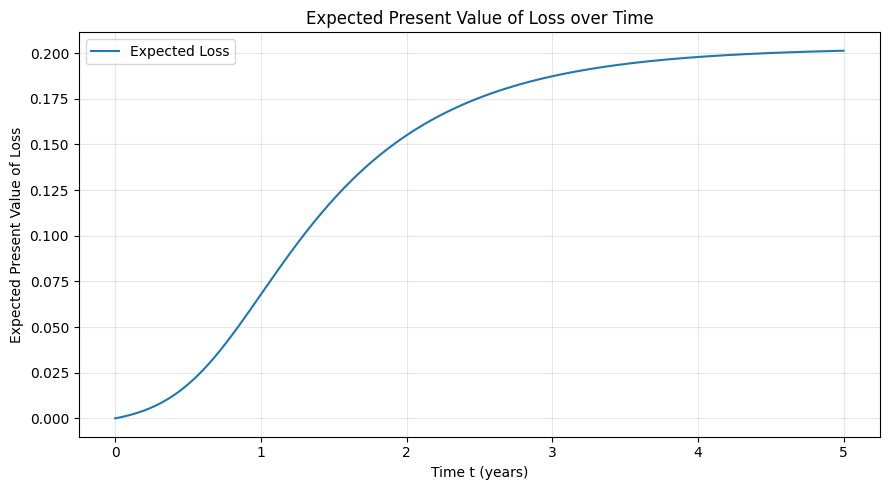

In [12]:
EPV_ben = spi.cumulative_trapezoid(integrand_ben,t, initial = 0)
EPV_prem = spi.cumulative_trapezoid(integrand_prem,t, initial = 0)

Loss_T = EPV_ben + EPV_prem  

plt.figure(figsize=(9,5))
plt.plot(t, Loss_T, label="Expected Loss")


plt.xlabel("Time t (years)")
plt.ylabel("Expected Present Value of Loss")
plt.title("Expected Present Value of Loss over Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 4.6 4.8 5.  5.2 5.4 5.6 5.8 6.  6.2 6.4 6.6 6.8 7.
 7.2 7.4 7.6 7.8 8.  8.2 8.4 8.6 8.8 9.  9.2 9.4 9.6 9.8]


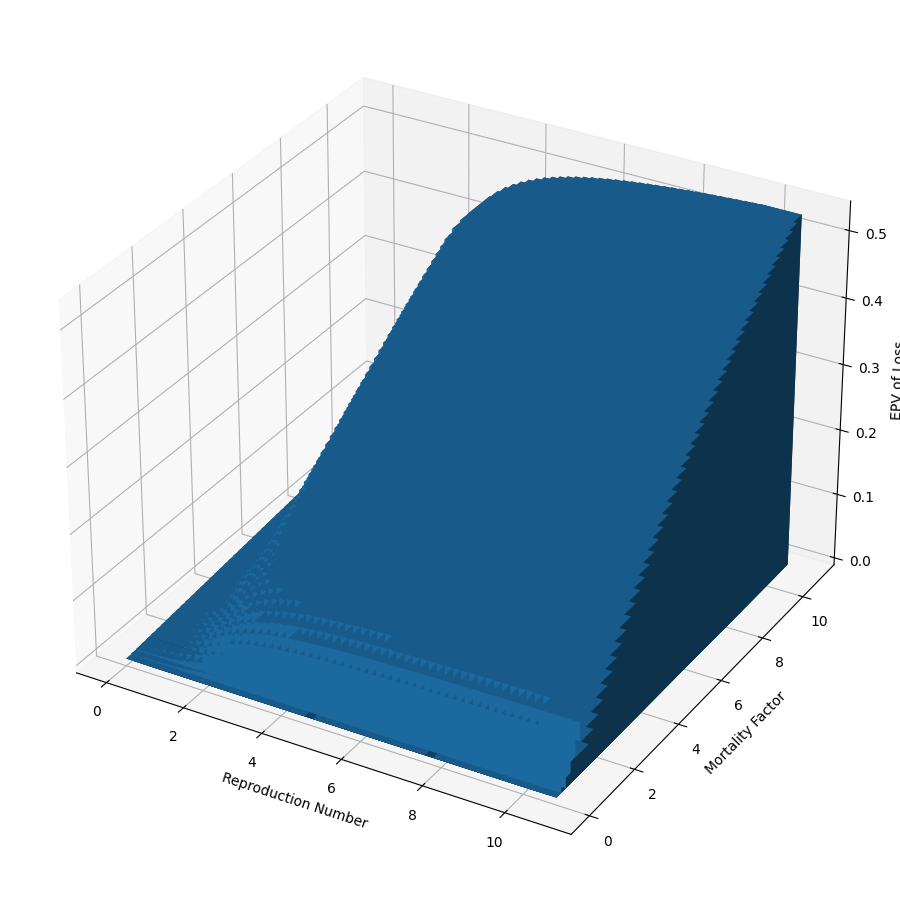

0.5394925531442913


'print(y0[999,3])\ntpx = y0[:,3]\nmu_xt = mu*(1+mort_factor*y0[:,1])\ndiscount = np.exp(-delta *t)\nintegrand_ben = DB* tpx * mu_xt *discount\nintegrand_prem = P * tpx * discount\nEPV_ben = spi.trapezoid(integrand_ben,t)\nEPV_prem = spi.trapezoid(integrand_prem,t)\nprint(EPV_ben)\nprint(EPV_prem)\nprint("Loss of: ", EPV_ben + EPV_prem)'

In [13]:
mu = 0.1
mort_factor = 3
delta = 0.05 # force of interest
ddt = lambda p,t: np.array([-mu*p[0], mu*p[0]])
#ic = np.array([0.95,0.05,0,1,0]) # S,I,R,Alive, dead
R0 = 5
DB = 1 #death benefit
P = -mu*DB #premium calculated using equiv principle, assuming no pandemic

def ddt(u,t,params):
    (R0, mort_factor) = params
    dudt = np.zeros(5)
    dudt[0] = -R0 * u[0]*u[1]
    dudt[1] = R0*u[0] * u[1] - u[1]
    dudt[2] = u[1]
    dudt[3] = -mu*(1+mort_factor*u[1])*u[3]
    dudt[4] = mu*(1+mort_factor*u[1])*u[3]
    return dudt

def find_EPV(r,m,infected = 0.05): #finds the EPV of loss for a given mort factor, reproduction number, % of pop initially infected 
  t = np.linspace(0,5,1000)
  R0 = r
  mort_factor = m
  ic = np.array([1-infected,infected,0,1,0])
  y0 = spi.odeint(lambda u,t: ddt(u,t,(R0,mort_factor)), ic, t)
  tpx = y0[:,3]
  mu_xt = mu*(1+mort_factor*y0[:,1])
  discount = np.exp(-delta *t)
  integrand_ben = DB* tpx * mu_xt *discount
  integrand_prem = P * tpx * discount
  EPV_ben = spi.trapezoid(integrand_ben,t)
  EPV_prem = spi.trapezoid(integrand_prem,t)
  return EPV_ben + EPV_prem
#making 3d graph of EPV for different R0, mort factors
granularity = 0.2

_R0_vals = np.arange(0,10,granularity)
print(_R0_vals)
_mort_vals = np.arange(0,10,granularity)
_xx, _yy = np.meshgrid(_R0_vals, _mort_vals)

R0_vals, mort_vals = _xx.ravel(), _yy.ravel()

_top = np.zeros_like(_xx,dtype=float)

for i in range(len(_R0_vals)):
   for j in range(len(_mort_vals)):
      _top[j][i] = find_EPV(_R0_vals[i],_mort_vals[j])

top = _top.ravel()


bottom = np.zeros_like(top)
width = depth = 1
fig = plt.figure(figsize=(25, 30))
ax1 = fig.add_subplot(121, projection='3d')
ax1.bar3d(R0_vals, mort_vals, bottom, width, depth, top, shade=True)

ax1.set_xlabel("Reproduction Number")
ax1.set_ylabel("Mortality Factor")
ax1.set_zlabel("EPV of Loss")
plt.show()


print(find_EPV(10,10))
'''print(y0[999,3])
tpx = y0[:,3]
mu_xt = mu*(1+mort_factor*y0[:,1])
discount = np.exp(-delta *t)
integrand_ben = DB* tpx * mu_xt *discount
integrand_prem = P * tpx * discount
EPV_ben = spi.trapezoid(integrand_ben,t)
EPV_prem = spi.trapezoid(integrand_prem,t)
print(EPV_ben)
print(EPV_prem)
print("Loss of: ", EPV_ben + EPV_prem)'''



(50, 50)
10


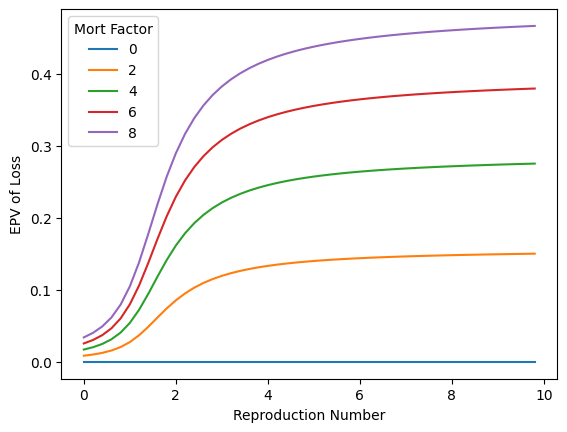

In [8]:
# Affect of R0 for fixed mortality factor

#TODO: add vertical marker for inflection point R0 * S = 1, do more analysis related to this inflection point
x = _R0_vals
print(_top.shape)
increment = _top.shape[0]//5
print(increment)
for i in range(5):

  y = _top[increment*i,:]
  l = str(i*2)
  plt.plot(x,y, label=l)


plt.legend(title="Mort Factor")
plt.xlabel("Reproduction Number")
plt.ylabel("EPV of Loss")
plt.show()



(50, 50)
10


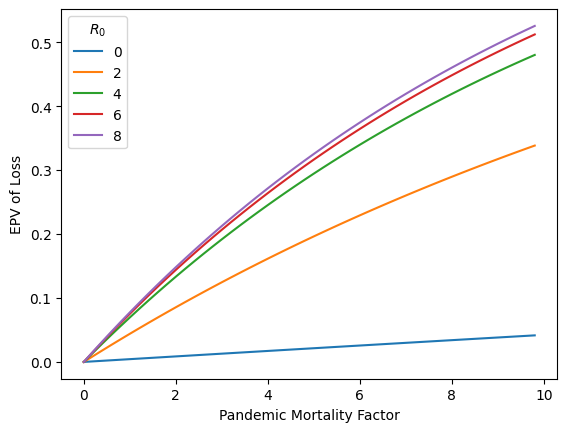

In [9]:
# Affect of Mortality factor for fixed R0

x = _mort_vals
print(_top.shape)
increment = _top.shape[0]//5
print(increment)
for i in range(5):

  y = _top[:,increment*i]
  l = str(i*2)
  plt.plot(x,y, label=l)

plt.legend(title="$R_0$")
plt.xlabel("Pandemic Mortality Factor")
plt.ylabel("EPV of Loss")

plt.show()
